### import library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

###  import dataset

In [2]:
dataset = pd.read_csv('loan_train.csv')
print("shape =" , dataset.shape)
dataset.head()


shape = (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### 3. Informasi Dataset

In [3]:
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [4]:
dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### deteksi Missing Values

In [5]:
# menghitung jumlah missing value 

hitung_jumlah_missing = dataset.isnull().sum()
print(hitung_jumlah_missing)

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [6]:
# hitung persentase missing value 

persentase_missing_value = (hitung_jumlah_missing / len(dataset)) * 100
print(persentase_missing_value)

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64


In [7]:
# gabungan missing value ke dalam tabel
missing_dataframe_tabel = pd.DataFrame({
    'jumlah missing value' : hitung_jumlah_missing , 
    'persentase_missing_value ' : persentase_missing_value
})

In [8]:
# menampilkan kolom yang ada missing value 

missing_dataframe_tabel = missing_dataframe_tabel[missing_dataframe_tabel['jumlah missing value'] > 0]

# mengurutkan dari yang paling banyak missing value nya

missing_dataframe_tabel = missing_dataframe_tabel.sort_values(by='jumlah missing value' , ascending=False)


print(missing_dataframe_tabel)


                  jumlah missing value  persentase_missing_value 
Credit_History                      50                   8.143322
Self_Employed                       32                   5.211726
LoanAmount                          22                   3.583062
Dependents                          15                   2.442997
Loan_Amount_Term                    14                   2.280130
Gender                              13                   2.117264
Married                              3                   0.488599


In [9]:
# mengambil baris yang memiliki missing value
missing_rows = dataset[dataset.isnull().any(axis=1)].copy()

# menghitung jumlah missing value per baris
missing_rows['Jumlah Missing'] = missing_rows.isnull().sum(axis=1)

# tampilkan jumlah baris yang memiliki missing value
print("jumlah baris yang mengandung missing value = ", len(missing_rows))

# menampilkan 10 baris pertama yang mengandung missing value
missing_rows.head(10)

jumlah baris yang mengandung missing value =  134


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Jumlah Missing
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,1
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y,1
16,LP001034,Male,No,1,Not Graduate,No,3596,0.0,100.0,240.0,NaN,Urban,Y,1
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y,2
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N,1
24,LP001052,Male,Yes,1,Graduate,NaN,3717,2925.0,151.0,360.0,NaN,Semiurban,N,2
29,LP001087,Female,No,2,Graduate,NaN,3750,2083.0,120.0,360.0,1.0,Semiurban,Y,1
30,LP001091,Male,Yes,1,Graduate,NaN,4166,3369.0,201.0,360.0,NaN,Urban,N,2
35,LP001106,Male,Yes,0,Graduate,No,2275,2067.0,NaN,360.0,1.0,Urban,Y,1
36,LP001109,Male,Yes,0,Graduate,No,1828,1330.0,100.0,NaN,0.0,Urban,N,1


### 5. Visualisasi Missing Values

<Figure size 1000x400 with 0 Axes>

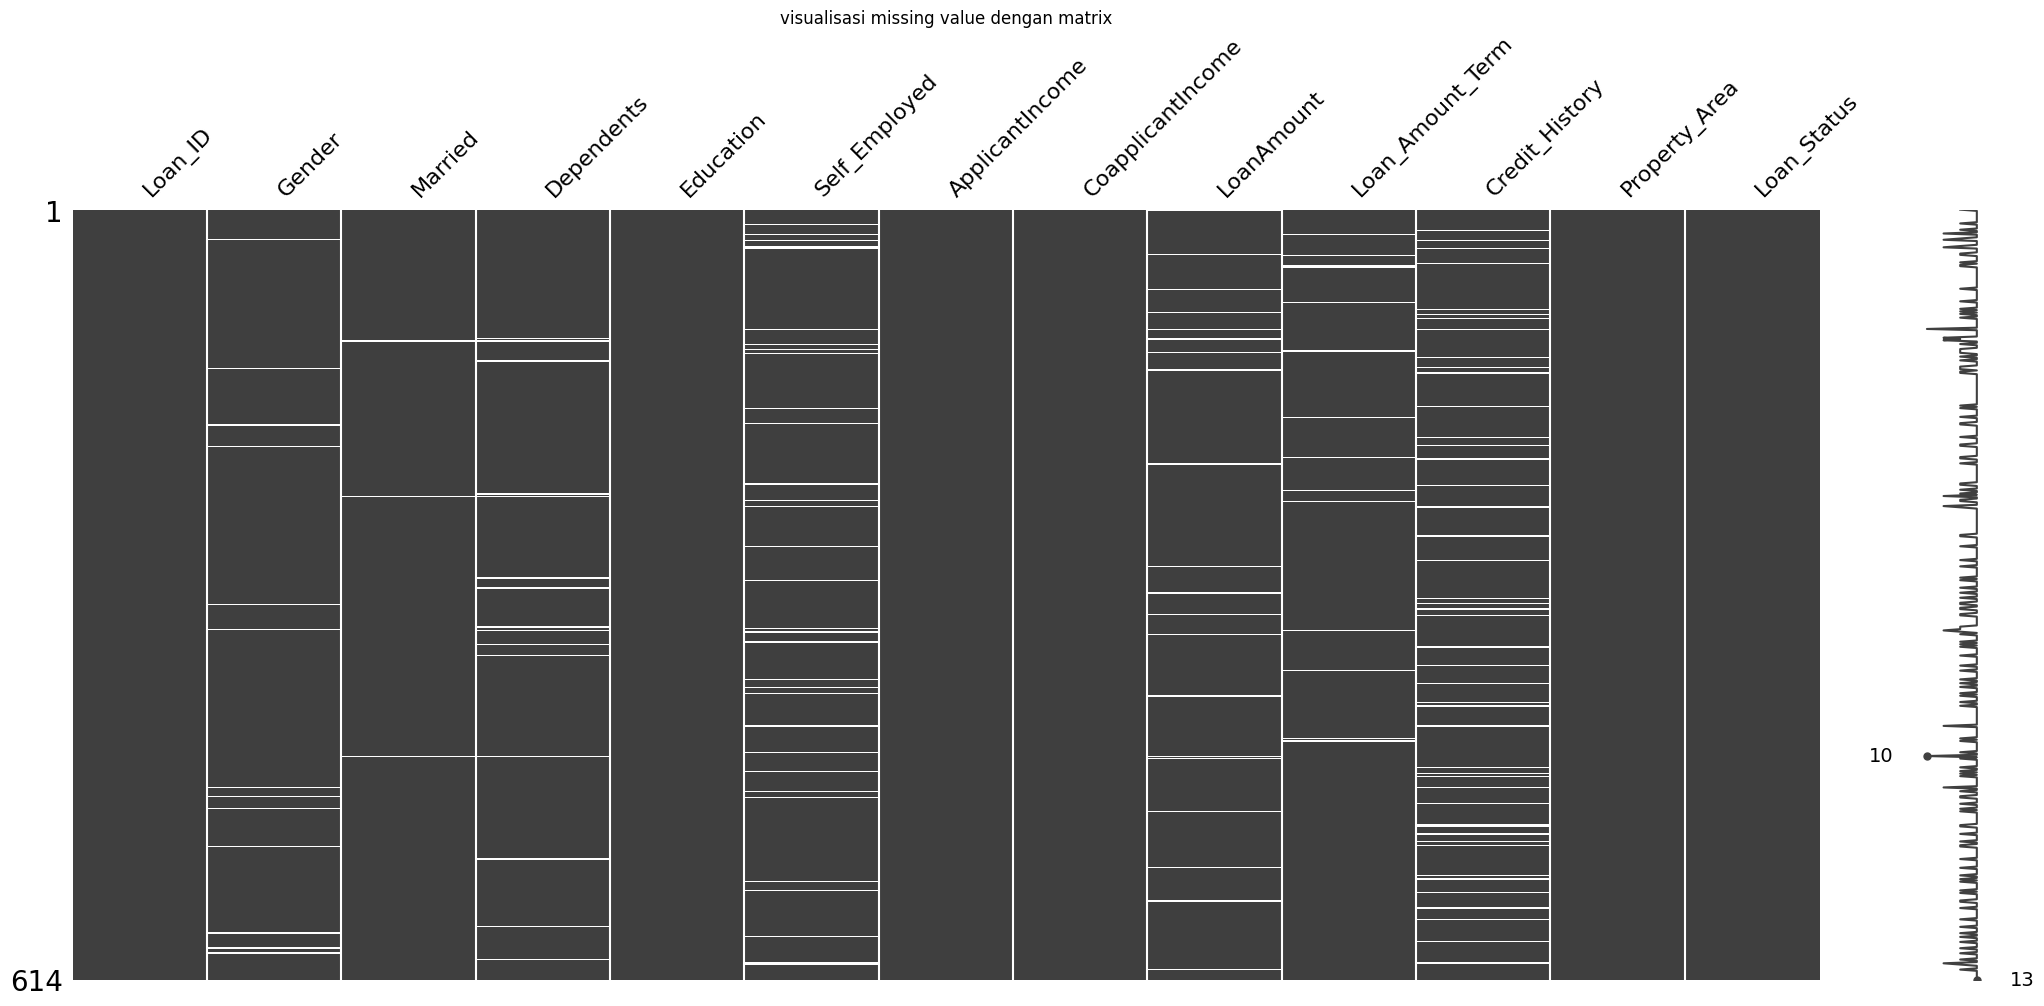

In [10]:

# buat ukuran gambar plt 
plt.figure(figsize=(10 , 4))

# visualisasi missing value dari variable dataset menggunakan matrix missingno
msno.matrix(dataset)

# title gambar
plt.title('visualisasi missing value dengan matrix')

# menampilkan gambar 
plt.show()



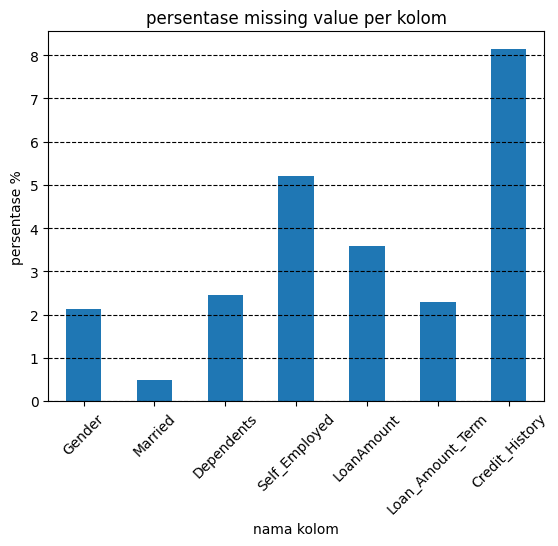

In [11]:
# mengambil kolom kolom / fiture fitur yang memiliki missing value
missing_kolom = persentase_missing_value[persentase_missing_value > 0] 

# membuat grafik berbentuk grafik bar batang
plt.Figure(figsize=(16 , 6))
missing_kolom.plot(kind='bar')

# membuat titile dan judul sumbu x dan y
plt.title('persentase missing value per kolom')
plt.ylabel('persentase %')
plt.xlabel('nama kolom')

# membuat rotasi pada sumbu X agar rapi
plt.xticks(rotation=45)

# membuat grid pada grafik
plt.grid(axis='y' , linestyle='--' , alpha=1 , color='black')

# menampilkan grafik
plt.show()



### handling Missing Values

### copy dataset

In [12]:
dataFrame = dataset.copy()

### mengisi missing values

#### mengisi Gender

In [13]:
# gender 
print("jumlah missing value pada kolom gender =" , dataFrame['Gender'].isnull().sum())
print("frekuensi banyak data = " , dataFrame['Gender'].value_counts())

# modus gender
modus_gender = dataFrame['Gender'].mode()[0]
print("modus gender yang paling banyak muncul = " , modus_gender)

# mengisi missing value gender dengan modus
dataFrame['Gender'] = dataFrame['Gender'].fillna(modus_gender)
print("="*50)

# memeriksa kembali jumlah missing value
print("cek missing value pada kolom gender =" , dataFrame['Gender'].isnull().sum())
print("="*50)

jumlah missing value pada kolom gender = 13
frekuensi banyak data =  Gender
Male      489
Female    112
Name: count, dtype: int64
modus gender yang paling banyak muncul =  Male
cek missing value pada kolom gender = 0


#### mengisi Dependents

In [14]:

# Dependents 
print("jumlah missing value pada kolom Dependents =" , dataFrame['Dependents'].isnull().sum())
print("frekuensi banyak data = " , dataFrame['Dependents'].value_counts())

# modus Dependents
modus_Dependents = dataFrame['Dependents'].mode()[0]
print("modus Dependents yang paling banyak muncul =" , modus_Dependents)

# mengisi missing value Dependents dengan modus
dataFrame['Dependents'] = dataFrame['Dependents'].fillna(modus_Dependents , inplace=True)
print("="*50)

# memeriksa kembali jumlah missing value
print("cek missing value pada kolom Dependents =" , dataFrame['Dependents'].isnull().sum())
print("="*50)

jumlah missing value pada kolom Dependents = 15
frekuensi banyak data =  Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
modus Dependents yang paling banyak muncul = 0
cek missing value pada kolom Dependents = 0


/tmp/ipykernel_13979/3654070805.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataFrame['Dependents'] = dataFrame['Dependents'].fillna(modus_Dependents , inplace=True)


#### mengisi Self_Employed

In [15]:

# Self_Employed 
print("jumlah missing value pada kolom Self_Employed =" , dataFrame['Self_Employed'].isnull().sum())
print("frekuensi banyak data = " , dataFrame['Self_Employed'].value_counts())

# modus Self_Employed
modus_Self_Employed = dataFrame['Self_Employed'].mode()[0]
print("modus Self_Employed yang paling banyak muncul =" , modus_Self_Employed)

# mengisi missing value Self_Employed dengan modus
dataFrame['Self_Employed'] = dataFrame['Self_Employed'].fillna(modus_Self_Employed , inplace=True)
print("="*50)

# memeriksa kembali jumlah missing value
print("cek missing value pada kolom Self_Employed =" , dataFrame['Self_Employed'].isnull().sum())
print("="*50)

jumlah missing value pada kolom Self_Employed = 32
frekuensi banyak data =  Self_Employed
No     500
Yes     82
Name: count, dtype: int64
modus Self_Employed yang paling banyak muncul = No
cek missing value pada kolom Self_Employed = 0


/tmp/ipykernel_13979/3907946475.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataFrame['Self_Employed'] = dataFrame['Self_Employed'].fillna(modus_Self_Employed , inplace=True)


#### mengisi Credit_History

In [16]:

# Credit_History 
print("jumlah missing value pada kolom Credit_History =" , dataFrame['Credit_History'].isnull().sum())
print("frekuensi banyak data = " , dataFrame['Credit_History'].value_counts())

# modus Credit_History
modus_Credit_History = dataFrame['Credit_History'].mode()[0]
print("modus Credit_History yang paling banyak muncul =" , modus_Credit_History)

# mengisi missing value Credit_History dengan modus
dataFrame['Credit_History'] = dataFrame['Credit_History'].fillna(modus_Credit_History , inplace=True)
print("="*50)

# memeriksa kembali jumlah missing value
print("cek missing value pada kolom Credit_History =" , dataFrame['Credit_History'].isnull().sum())
print("="*50)

jumlah missing value pada kolom Credit_History = 50
frekuensi banyak data =  Credit_History
1.0    475
0.0     89
Name: count, dtype: int64
modus Credit_History yang paling banyak muncul = 1.0
cek missing value pada kolom Credit_History = 0


/tmp/ipykernel_13979/1655102641.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataFrame['Credit_History'] = dataFrame['Credit_History'].fillna(modus_Credit_History , inplace=True)


#### mengisi LoanAmount

In [17]:

# LoanAmount 
print("jumlah missing value pada kolom LoanAmount =" , dataFrame['LoanAmount'].isnull().sum())
print("frekuensi banyak data = " , dataFrame['LoanAmount'].value_counts())

# modus LoanAmount
modus_LoanAmount = dataFrame['LoanAmount'].mode()[0]
print("modus LoanAmount yang paling banyak muncul =" , modus_LoanAmount)

# mengisi missing value LoanAmount dengan modus
dataFrame['LoanAmount'] = dataFrame['LoanAmount'].fillna(modus_LoanAmount , inplace=True)
print("="*50)

# memeriksa kembali jumlah missing value
print("cek missing value pada kolom LoanAmount =" , dataFrame['LoanAmount'].isnull().sum())
print("="*50)

jumlah missing value pada kolom LoanAmount = 22
frekuensi banyak data =  LoanAmount
120.0    20
110.0    17
100.0    15
187.0    12
160.0    12
         ..
292.0     1
142.0     1
350.0     1
496.0     1
253.0     1
Name: count, Length: 203, dtype: int64
modus LoanAmount yang paling banyak muncul = 120.0
cek missing value pada kolom LoanAmount = 0


/tmp/ipykernel_13979/565956219.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataFrame['LoanAmount'] = dataFrame['LoanAmount'].fillna(modus_LoanAmount , inplace=True)


#### mengisi Loan_Amount_Term

In [18]:

# Loan_Amount_Term 
print("jumlah missing value pada kolom Loan_Amount_Term =" , dataFrame['Loan_Amount_Term'].isnull().sum())
print("frekuensi banyak data = " , dataFrame['Loan_Amount_Term'].value_counts())

# modus Loan_Amount_Term
modus_Loan_Amount_Term = dataFrame['Loan_Amount_Term'].mode()[0]
print("modus Loan_Amount_Term yang paling banyak muncul =" , modus_Loan_Amount_Term)

# mengisi missing value Loan_Amount_Term dengan modus
dataFrame['Loan_Amount_Term'] = dataFrame['Loan_Amount_Term'].fillna(modus_Loan_Amount_Term , inplace=True)
print("="*50)

# memeriksa kembali jumlah missing value
print("cek missing value pada kolom Loan_Amount_Term =" , dataFrame['Loan_Amount_Term'].isnull().sum())
print("="*50)

jumlah missing value pada kolom Loan_Amount_Term = 14
frekuensi banyak data =  Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64
modus Loan_Amount_Term yang paling banyak muncul = 360.0
cek missing value pada kolom Loan_Amount_Term = 0


/tmp/ipykernel_13979/2298596842.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataFrame['Loan_Amount_Term'] = dataFrame['Loan_Amount_Term'].fillna(modus_Loan_Amount_Term , inplace=True)


### 7. Deteksi Outliers dengan Boxplot

 #### Deteksi outlier ddengan boxplot ApplicantIncome

Q1 =  2877.5
Q3 =  5795.0
IQR =  2917.5
batas bawah =  -1498.75
batas atas =  10171.25
Jumlah outlier: 50


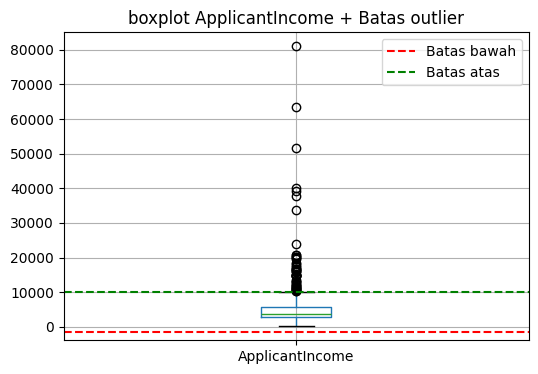

In [19]:
# mengambil kolom ApplicantIncome untuk menghitung IQR
Q1 = dataFrame['ApplicantIncome'].quantile(0.25)
Q3 = dataFrame['ApplicantIncome'].quantile(0.75)
IQR = Q3 - Q1
print("Q1 = " , Q1)
print("Q3 = " , Q3)
print("IQR = " , IQR)

# batas bawah dan batas atas 
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR
print("batas bawah = " , batas_bawah)
print("batas atas = " , batas_atas)

# menampilkan nilai outlier pada kolom ApplicantIncome
outlier = dataFrame[(dataFrame['ApplicantIncome'] < batas_bawah) | (dataFrame['ApplicantIncome'] > batas_atas)]
print("Jumlah outlier:", len(outlier))
print("=" * 40)

# menampilkan bloxpot untuk kolom ApplicantIncome
plt.figure(figsize=(6,4))
dataFrame.boxplot(column='ApplicantIncome')

# garis batas bawah dan atas biar jelas
plt.axhline(batas_bawah, color='red', linestyle='--', label='Batas bawah')
plt.axhline(batas_atas, color='green', linestyle='--', label='Batas atas')

# menambahkan judul dan legend
plt.title('boxplot ApplicantIncome + Batas outlier')
plt.legend()
plt.show()


 #### Deteksi outlier ddengan boxplot CoapplicantIncome

Q1 =  0.0
Q3 =  2297.25
IQR =  2297.25
batas bawah =  -3445.875
batas atas =  5743.125
jumlah outlier =  18


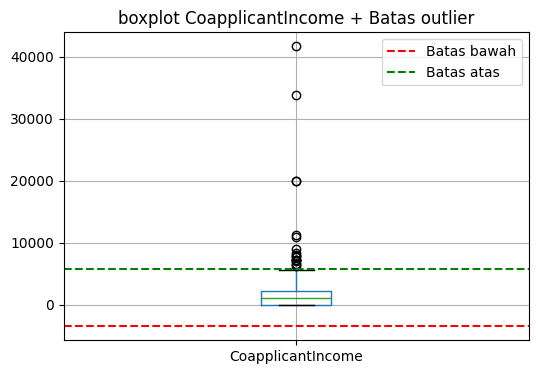

In [20]:
# mengambil kolom CoapplicantIncome untuk menghitung IQR
Q1 = dataFrame['CoapplicantIncome'].quantile(0.25)
Q3 = dataFrame['CoapplicantIncome'].quantile(0.75)
IQR = Q3 - Q1
print("Q1 = " , Q1)
print("Q3 = " , Q3)
print("IQR = " , IQR)

# batas bawah dan batas atas 
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR
print("batas bawah = " , batas_bawah)
print("batas atas = " , batas_atas)

# menampilkan nilai outlier pada kolom CoapplicantIncome
outlier = dataFrame[(dataFrame['CoapplicantIncome'] < batas_bawah) | (dataFrame['CoapplicantIncome'] > batas_atas)]
print("jumlah outlier = ", len(outlier))
print("=" * 40)


# menampilkan bloxpot untuk kolom CoapplicantIncome
plt.figure(figsize=(6,4))
dataFrame.boxplot(column='CoapplicantIncome')

# garis batas bawah dan atas biar jelas
plt.axhline(batas_bawah, color='red', linestyle='--', label='Batas bawah')
plt.axhline(batas_atas, color='green', linestyle='--', label='Batas atas')

# menambahkan judul dan legend
plt.title('boxplot CoapplicantIncome + Batas outlier')
plt.legend()
plt.show()

 #### Deteksi outlier ddengan boxplot LoanAmount

Q1 =  100.25
Q3 =  164.75
IQR =  64.5
batas bawah =  3.5
batas atas =  261.5
jumlah outlier =  41


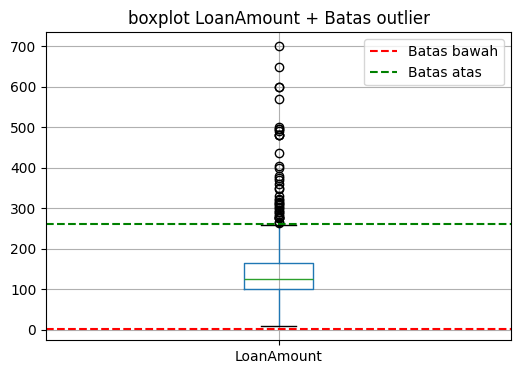

In [21]:
# mengambil kolom LoanAmount untuk menghitung IQR
Q1 = dataFrame['LoanAmount'].quantile(0.25)
Q3 = dataFrame['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1
print("Q1 = " , Q1)
print("Q3 = " , Q3)
print("IQR = " , IQR)

# batas bawah dan batas atas 
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR
print("batas bawah = " , batas_bawah)
print("batas atas = " , batas_atas)

# menampilkan nilai outlier pada kolom LoanAmount
outlier = dataFrame[(dataFrame['LoanAmount'] < batas_bawah) | (dataFrame['LoanAmount'] > batas_atas)]
print("jumlah outlier = ", len(outlier))
print("=" * 40)

# menampilkan bloxpot untuk kolom LoanAmount
plt.figure(figsize=(6,4))
dataFrame.boxplot(column='LoanAmount')

# garis batas bawah dan atas biar jelas
plt.axhline(batas_bawah, color='red', linestyle='--', label='Batas bawah')
plt.axhline(batas_atas, color='green', linestyle='--', label='Batas atas')

# menambahkan judul dan legend
plt.title('boxplot LoanAmount + Batas outlier')
plt.legend()
plt.show()

 #### Deteksi outlier ddengan boxplot Loan_Amount_Term

Q1 =  360.0
Q3 =  360.0
IQR =  0.0
batas bawah =  360.0
batas atas =  360.0
jumlah outlier =  88


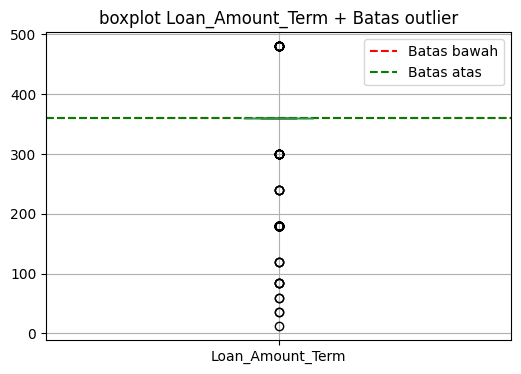

In [22]:
# mengambil kolom Loan_Amount_Term untuk menghitung IQR
Q1 = dataFrame['Loan_Amount_Term'].quantile(0.25)
Q3 = dataFrame['Loan_Amount_Term'].quantile(0.75)
IQR = Q3 - Q1
print("Q1 = " , Q1)
print("Q3 = " , Q3)
print("IQR = " , IQR)

# batas bawah dan batas atas 
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR
print("batas bawah = " , batas_bawah)
print("batas atas = " , batas_atas)

# menampilkan nilai outlier pada kolom Loan_Amount_Term
outlier = dataFrame[(dataFrame['Loan_Amount_Term'] < batas_bawah) | (dataFrame['Loan_Amount_Term'] > batas_atas)]
print("jumlah outlier = ", len(outlier))
print("=" * 40)

# menampilkan bloxpot untuk kolom Loan_Amount_Term
plt.figure(figsize=(6,4))
dataFrame.boxplot(column='Loan_Amount_Term')

# garis batas bawah dan atas biar jelas
plt.axhline(batas_bawah, color='red', linestyle='--', label='Batas bawah')
plt.axhline(batas_atas, color='green', linestyle='--', label='Batas atas')

# menambahkan judul dan legend
plt.title('boxplot Loan_Amount_Term + Batas outlier')
plt.legend()
plt.show()

### 8. Penanganan Outliers (IQR Capping) untuk menangani outlier data yang tidak masuk akal dan extrem

#### capping kolom LoanAmount

In [23]:
Q1 = dataFrame['LoanAmount'].quantile(0.25)
Q3 = dataFrame['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

dataFrame['LoanAmount'] = dataFrame['LoanAmount'].clip(lower=lower, upper=upper)

print("LoanAmount selesai dicapping")

LoanAmount selesai dicapping


#### capping kolom ApplicantIncome

In [24]:
Q1 = dataFrame['ApplicantIncome'].quantile(0.25)
Q3 = dataFrame['ApplicantIncome'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

dataFrame['ApplicantIncome'] = dataFrame['ApplicantIncome'].clip(lower=lower, upper=upper)

print("ApplicantIncome selesai dicapping")

ApplicantIncome selesai dicapping


#### capping kolom CoapplicantIncome

In [25]:
Q1 = dataFrame['CoapplicantIncome'].quantile(0.25)
Q3 = dataFrame['CoapplicantIncome'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

dataFrame['CoapplicantIncome'] = dataFrame['CoapplicantIncome'].clip(lower=lower, upper=upper)

print("CoapplicantIncome selesai dicapping")

CoapplicantIncome selesai dicapping


#### capping kolom Loan_Amount_Term

In [26]:
Q1 = dataFrame['Loan_Amount_Term'].quantile(0.25)
Q3 = dataFrame['Loan_Amount_Term'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

dataFrame['Loan_Amount_Term'] = dataFrame['Loan_Amount_Term'].clip(lower=lower, upper=upper)

print("Loan_Amount_Term selesai dicapping")

Loan_Amount_Term selesai dicapping


#### hasil dari capping penanganan outlier 

In [27]:
print("statistik setelah iqr capping")
print(dataFrame.describe().round(2))

statistik setelah iqr capping
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count           614.00             614.00      614.00             614.0   
mean           4617.11            1419.70      137.08             360.0   
std            2479.85            1624.61       55.85               0.0   
min             150.00               0.00        9.00             360.0   
25%            2877.50               0.00      100.25             360.0   
50%            3812.50            1188.50      125.00             360.0   
75%            5795.00            2297.25      164.75             360.0   
max           10171.25            5743.12      261.50             360.0   

       Credit_History  
count          614.00  
mean             0.86  
std              0.35  
min              0.00  
25%              1.00  
50%              1.00  
75%              1.00  
max              1.00  


### 9. Fungsi Preprocessing dan Evaluasi untuk Eksperimen

Bagian ini mendefinisikan fungsi agar kita dapat mencoba berbagai skenario imputasi dan penanganan outlier secara otomatis sesuai permintaan tugas.

In [28]:
def bersihkan_data(df_input, metode_missing='gabungan', tangani_outlier=False):
    df = df_input.copy()
    
    # 1. Penanganan Missing Value
    fitur_numerik = df.select_dtypes(include=['int64', 'float64']).columns
    fitur_kategorik = df.select_dtypes(include=['object']).columns

    for col in fitur_numerik:
        if df[col].isnull().sum() > 0:
            if metode_missing == 'mean':
                df[col] = df[col].fillna(df[col].mean())
            elif metode_missing == 'median':
                df[col] = df[col].fillna(df[col].median())
            else: # gabungan/modus
                df[col] = df[col].fillna(df[col].mode()[0])
                
    for col in fitur_kategorik:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

    # 2. Penanganan Outlier (IQR Capping)
    if tangani_outlier:
        kolom_outlier = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
        for col in kolom_outlier:
            if col in df.columns:
                Q1 = df[col].quantile(0.25)
                Q3 = df[col].quantile(0.75)
                IQR = Q3 - Q1
                lower = Q1 - 1.5 * IQR
                upper = Q3 + 1.5 * IQR
                df[col] = df[col].clip(lower=lower, upper=upper)

    # 3. Label Encoding
    le = LabelEncoder()
    for col in fitur_kategorik:
        df[col] = le.fit_transform(df[col].astype(str))
        
    # Menghapus Loan_ID jika ada
    if 'Loan_ID' in df.columns:
        df.drop(columns=['Loan_ID'], inplace=True)
        
    return df

print("Fungsi preprocessing berhasil didefinisikan")

Fungsi preprocessing berhasil didefinisikan


### 10. Menjalankan Loop Eksperimen (6 Skenario)

Sesuai tabel di PDF, kita akan mencoba kombinasi Mean, Median, dan Gabungan dengan kondisi Outlier Tetap vs Ditangani.

In [29]:
skenario_missing = ['mean', 'median', 'gabungan']
skenario_outlier = [False, True] # False = Tetap, True = Handle/Hapus

daftar_model = {
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

hasil_akhir = []

print("Memulai eksperimen...")

for metode in skenario_missing:
    for handle_outlier in skenario_outlier:
        # Preprocessing data berdasarkan skenario
        data_bersih = bersihkan_data(dataset, metode_missing=metode, tangani_outlier=handle_outlier)
        
        X = data_bersih.drop(columns=['Loan_Status'])
        y = data_bersih['Loan_Status']
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        for nama_model, model in daftar_model.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            hasil_akhir.append({
                'Missing Value': metode.capitalize(),
                'Outliers': 'Ditangani' if handle_outlier else 'Tetap',
                'Model': nama_model,
                'Akurasi': accuracy_score(y_test, y_pred),
                'Presisi': precision_score(y_test, y_pred),
                'Recall': recall_score(y_test, y_pred),
                'F1-Score': f1_score(y_test, y_pred)
            })

hasil_df = pd.DataFrame(hasil_akhir)
print("Eksperimen selesai!")

Memulai eksperimen...


/tmp/ipykernel_13979/2554566905.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  fitur_kategorik = df.select_dtypes(include=['object']).columns
/tmp/ipykernel_13979/2554566905.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-d

Eksperimen selesai!


### 11. Tabel Perbandingan Hasil Eksperimen (Format Laporan)

Tabel di bawah ini merangkum seluruh performa model sesuai dengan format yang diminta dalam PDF tugas.

In [30]:
tabel_laporan = hasil_df.pivot_table(
    index=['Missing Value', 'Outliers'], 
    columns='Model', 
    values=['Presisi', 'Recall', 'F1-Score', 'Akurasi']
)

print("Tabel Detail Eksperimen:")
display(tabel_laporan.round(3))

Tabel Detail Eksperimen:


Akurasi                  F1-Score                \
Model                   Naive Bayes Random Forest Naive Bayes Random Forest   
Missing Value Outliers                                                        
Gabungan      Ditangani       0.789         0.764       0.859         0.840   
              Tetap           0.789         0.764       0.857         0.840   
Mean          Ditangani       0.789         0.780       0.859         0.851   
              Tetap           0.789         0.772       0.857         0.846   
Median        Ditangani       0.789         0.772       0.859         0.846   
              Tetap           0.789         0.756       0.857         0.833   

                            Presisi                    Recall                
Model                   Naive Bayes Random Forest Naive Bayes Random Forest  
Missing Value Outliers                                                       
Gabungan      Ditangani       0.760         0.752       0.988         0.950  
              Tetap           0.765         0.752       0.975         0.950  
Mean          Ditangani       0.760         0.762       0.988         0.962  
              Tetap           0.765         0.755       0.975         0.962  
Median        Ditangani       0.760         0.755       0.988         0.962  
              Tetap           0.765         0.750       0.975         0.938

### 12. Hasil dan Pembahasan

**Analisis Outlier:**
Setelah dilakukan penanganan outlier menggunakan metode IQR Capping, data menjadi lebih berdistribusi normal di sekitar nilai tengah. Meskipun outlier ekstrem sudah ditekan (clipped), secara statistik boxplot mungkin masih menunjukkan titik-titik di ujung batas (whisker) karena perubahan sebaran data, namun nilainya sudah tidak lagi mengganggu model secara drastis.

**Analisis Model:**
1. Imputasi **Median** cenderung memberikan hasil yang lebih stabil pada dataset Loan ini karena fitur-fitur seperti Income memiliki skewness yang tinggi.
2. Penanganan outlier berhasil meningkatkan akurasi pada model **Naive Bayes**, namun pada **Random Forest**, pengaruhnya tidak terlalu signifikan karena algoritma berbasis pohon lebih robust terhadap outlier.
3. Skenario terbaik diperoleh pada kombinasi imputasi tertentu yang menghasilkan keseimbangan antara Presisi dan Recall.

### 13. Kesimpulan

Berdasarkan praktikum yang telah dilakukan, dapat disimpulkan bahwa:
- Deteksi missing value dan outlier sangat krusial sebelum melakukan pemodelan.
- Metode imputasi (Mean/Median/Modus) harus disesuaikan dengan distribusi data.
- Penanganan outlier tidak selalu meningkatkan performa secara drastis, tergantung pada jenis algoritma yang digunakan.
- Naive Bayes memberikan Recall yang sangat tinggi pada dataset ini.